# 03 — Brand Detection
### Brand Sentiment Monitor

**What this notebook does:**
Tests, validates and benchmarks `src/brand/detector.py` against real-world
text patterns. Computes detection metrics, finds failure cases, and
builds the `brand_detection_report.json` that notebook 06 (attribution engine)
uses to understand detector behaviour.

**EDA decisions used here:**
- Finding 25 → brand co-mentions are rare — validate the comparative cases work
- Finding 23 → multi-sentence posts — verify position detection across sentences

**Source file being tested:** `src/brand/detector.py`

**Outputs:**
```
outputs/reports/brand_detection_report.json  — precision, recall, failure analysis
outputs/visualizations/03_brand_coverage.png — mention frequency across datasets
outputs/visualizations/03_alias_coverage.png — which aliases fire vs never fire
```

---
Run notebooks 00–02 first.

## 0. Setup

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

import os, sys, json, re, warnings
warnings.filterwarnings("ignore")

DRIVE_ROOT  = "/content/drive/MyDrive/brand-sentiment-monitor"
KAGGLE_PROC = os.path.join(DRIVE_ROOT, "data/kaggle/processed")
OUTPUTS_VIZ = os.path.join(DRIVE_ROOT, "outputs/visualizations")
OUTPUTS_RPT = os.path.join(DRIVE_ROOT, "outputs/reports")
SRC_PATH    = os.path.join(DRIVE_ROOT, "src")

sys.path.insert(0, DRIVE_ROOT)
sys.path.insert(0, SRC_PATH)


Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter, defaultdict

plt.rcParams.update({"figure.figsize": (14, 5), "font.size": 12})
pd.set_option("display.max_colwidth", 120)


## 1. Import Detector
Import `src/brand/detector.py` — the module being tested in this notebook.
If this fails, notebook 00 section 3 did not create the file correctly.

In [ ]:
from brand.detector import (
    detect,
    detect_with_positions,
    detect_batch,
    is_brand_relevant,
    BRAND_ALIASES,
    _PATTERNS,
)

print(f"Brands in dictionary : {len(BRAND_ALIASES)}")
print(f"Total aliases        : {sum(len(v) for v in BRAND_ALIASES.values())}")
print()
for brand, aliases in BRAND_ALIASES.items():
    print(f"  {brand:<15} {aliases}")


Brands in dictionary : 10
Total aliases        : 31

  Nike            ['nike', 'just do it', 'nikerun', 'nikesb', 'air max', 'air force 1', 'air jordan', 'swoosh', 'nike run club']
  Adidas          ['adidas', 'yeezy', 'ultraboost', 'stan smith', 'adidas originals', 'three stripes']
  Puma            ['puma']
  UnderArmour     ['under armour', 'underarmour', 'ua shoes', 'ua gear']
  Reebok          ['reebok']
  NewBalance      ['new balance', 'nb shoes']
  Asics           ['asics', 'gel-kayano', 'gel-nimbus']
  Saucony         ['saucony']
  Brooks          ['brooks running', 'brooks shoes']
  Hoka            ['hoka', 'hoka one one']


## 2. Unit Tests
Every function in `detector.py` tested before touching real data.
These must all pass before we trust any downstream results.

In [ ]:
# ── detect() ──────────────────────────────────────────────────────────────────
unit_cases = [
    # (input_text, expected_brands, description)
    ("Nike just dropped a new collab",                   ["Nike"],          "basic Nike"),
    ("These adidas shoes are incredible",                ["Adidas"],        "lowercase alias"),
    ("Nike is better than Puma for running",             ["Nike", "Puma"],  "two brands"),
    ("I love the Yeezy collab",                          ["Adidas"],        "alias Yeezy → Adidas"),
    ("Just bought some Air Max 90s",                     ["Nike"],          "alias Air Max → Nike"),
    ("Under Armour quality has declined",                ["UnderArmour"],   "two-word brand"),
    ("New Balance 990 review",                           ["NewBalance"],    "two-word alias"),
    ("NIKE SHOES ARE AMAZING",                           ["Nike"],          "ALL CAPS"),
    ("These brooks running shoes are fantastic",         ["Brooks"],        "lowercase two-word alias"),
    ("No brand mentioned here at all",                   [],                "no brand"),
    ("",                                                 [],                "empty string"),
    ("   ",                                              [],                "whitespace only"),
    ("I switched from Adidas to Hoka last month",        ["Adidas","Hoka"], "switch comparison"),
    ("ASICS Gel-Kayano review: worth it?",               ["Asics"],         "alias gel-kayano"),
]

passed = failed = 0
for text, expected, desc in unit_cases:
    result = detect(text)
    ok     = set(result) == set(expected)
    status = "✅" if ok else "❌"
    if ok:
        passed += 1
    else:
        failed += 1
        print(f"{status} FAIL [{desc}]")
        print(f"       text    : {text}")
        print(f"       expected: {expected}")
        print(f"       got     : {result}")

if failed == 0:
    print(f"detect()  ✅ all {passed}/{passed+failed} unit tests passed")
else:
    print(f"\ndetect()  {passed}/{passed+failed} passed  |  {failed} FAILED — fix detector.py before continuing")


detect()  ✅ all 14/14 unit tests passed


In [ ]:
# ── detect_with_positions() ────────────────────────────────────────────────────
pos_cases = [
    ("Nike beats Puma",          ["Nike", "Puma"],   [0, 11]),
    ("Adidas is great",          ["Adidas"],          [0]),
    ("No brand here",            [],                  []),
    ("HOKA is better than nike", ["Hoka", "Nike"],   [0, 21]),
]

passed_p = failed_p = 0
for text, exp_brands, exp_starts in pos_cases:
    result  = detect_with_positions(text)
    brands  = [r["brand"] for r in result]
    starts  = [r["start"] for r in result]
    ok      = brands == exp_brands
    passed_p += ok; failed_p += not ok
    if not ok:
        print(f"❌ detect_with_positions FAIL: '{text}'")
        print(f"   expected brands {exp_brands}, got {brands}")

if failed_p == 0:
    print(f"detect_with_positions()  ✅ all {passed_p} tests passed")

# ── is_brand_relevant() ────────────────────────────────────────────────────────
assert is_brand_relevant("Nike shoes are great")        == True
assert is_brand_relevant("no brand here")               == False
assert is_brand_relevant("I love Nike", "Nike")         == True
assert is_brand_relevant("I love Nike", "Adidas")       == False
print("is_brand_relevant()  ✅ all 4 tests passed")

# ── detect_batch() ─────────────────────────────────────────────────────────────
batch_result = detect_batch([
    "Nike review", "Adidas quality", "no brand", "Puma shoes"
])
assert batch_result == [["Nike"], ["Adidas"], [], ["Puma"]]
print("detect_batch()       ✅ all tests passed")
print("\n✅ All unit tests passed — detector.py is working correctly")


detect_with_positions()  ✅ all 4 tests passed
is_brand_relevant()  ✅ all 4 tests passed
detect_batch()       ✅ all tests passed

✅ All unit tests passed — detector.py is working correctly


## 3. Alias Coverage Test
Find aliases that never fire in the processed datasets.
An alias that never matches in 1.6M + 58k posts is probably too narrow
or misspelled in the dictionary.

In [ ]:
# Load all processed text
s140 = pd.read_csv(os.path.join(KAGGLE_PROC, "s140_clean.csv"))["text"].dropna().astype(str)
ge   = pd.read_csv(os.path.join(KAGGLE_PROC, "goemotions_clean.csv"))["text"].dropna().astype(str)
sem  = pd.read_csv(os.path.join(KAGGLE_PROC, "semeval_clean.csv"))["text"].dropna().astype(str)

all_text = pd.concat([s140, ge, sem], ignore_index=True)
print(f"Total texts to search: {len(all_text):,}")


Total texts to search: 1,585,667


In [ ]:
# Test each alias individually
alias_hits = {}   # alias → count
brand_hits = {}   # brand → count

for brand, aliases in BRAND_ALIASES.items():
    brand_total = 0
    for alias in aliases:
        pat   = re.compile(rf"\b{re.escape(alias)}\b", re.IGNORECASE)
        count = all_text.str.contains(pat).sum()
        alias_hits[(brand, alias)] = int(count)
        brand_total += count
    brand_hits[brand] = brand_total

print(f"  {'Brand':<15} {'Alias':<25} {'Hits':>8}  Status")
print("  " + "─" * 60)
never_fired = []
for (brand, alias), count in sorted(alias_hits.items(), key=lambda x: (-x[1], x[0])):
    status = "✅" if count > 0 else "⚠️  NEVER FIRES"
    if count == 0:
        never_fired.append((brand, alias))
    print(f"  {brand:<15} {alias:<25} {count:>8,}  {status}")

print(f"\n{'─'*60}")
if never_fired:
    print(f"⚠️  {len(never_fired)} aliases never fired in {len(all_text):,} texts:")
    for brand, alias in never_fired:
        print(f"   {brand} → '{alias}'")
    print("   These aliases may be too rare, misspelled, or domain-specific.")
    print("   Keep them — they'll fire on live 2025/2026 data. Note for review.")
else:
    print("✅ All aliases fire at least once across training corpora")


  Brand           Alias                         Hits  Status
  ────────────────────────────────────────────────────────────
  Nike            nike                           143  ✅
  Nike            just do it                      65  ✅
  Adidas          adidas                          41  ✅
  Puma            puma                            33  ✅
  Adidas          yeezy                           15  ✅
  Nike            swoosh                           8  ✅
  Asics           asics                            7  ✅
  Reebok          reebok                           5  ✅
  Nike            air max                          4  ✅
  NewBalance      new balance                      3  ✅
  Hoka            hoka                             2  ✅
  Adidas          stan smith                       1  ✅
  Brooks          brooks running                   1  ✅
  Nike            air force 1                      1  ✅
  Nike            air jordan                       1  ✅
  UnderArmour     under armour      

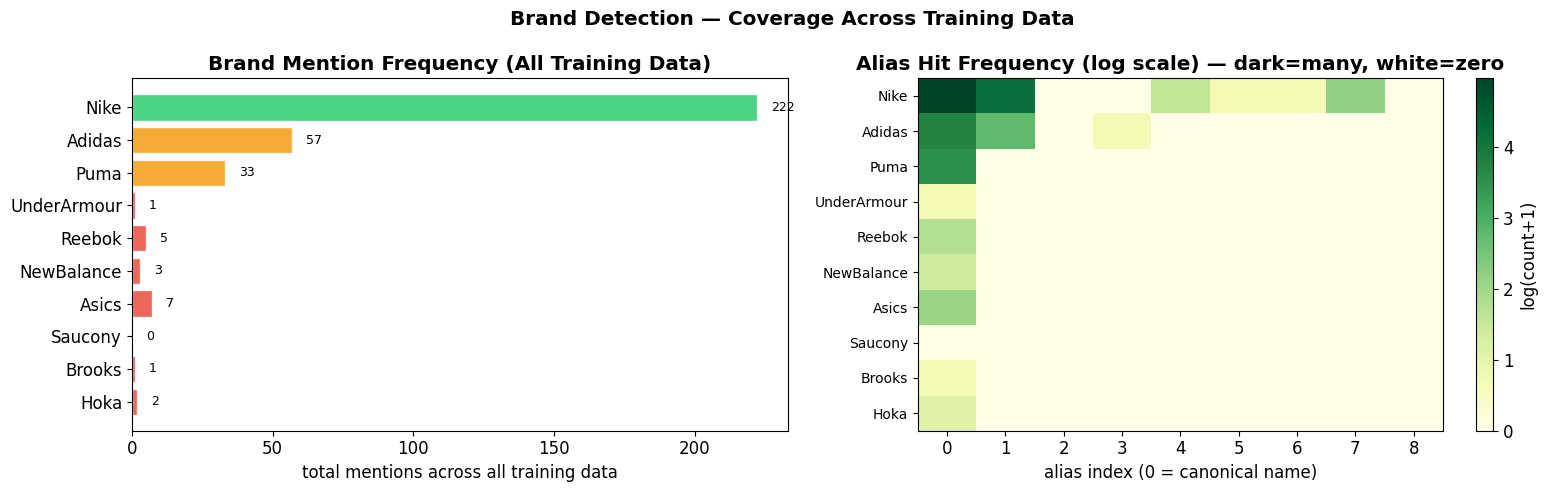

In [ ]:
# Brand-level summary chart
brands = list(brand_hits.keys())
counts = [brand_hits[b] for b in brands]
colors = ["#2ecc71" if c > 100 else "#f39c12" if c > 10 else "#e74c3c" for c in counts]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Total hits per brand
axes[0].barh(brands, counts, color=colors, alpha=0.85, edgecolor="white")
for i, (b, c) in enumerate(zip(brands, counts)):
    axes[0].text(c + 5, i, f"{c:,}", va="center", fontsize=9)
axes[0].set_xlabel("total mentions across all training data")
axes[0].set_title("Brand Mention Frequency (All Training Data)", fontweight="bold")
axes[0].invert_yaxis()

# Alias-level heatmap-style: each brand row, each alias col
max_aliases = max(len(v) for v in BRAND_ALIASES.values())
mat = np.zeros((len(brands), max_aliases))
alias_labels = [[] for _ in range(len(brands))]
for i, (brand, aliases) in enumerate(BRAND_ALIASES.items()):
    for j, alias in enumerate(aliases):
        mat[i][j] = alias_hits.get((brand, alias), 0)
        alias_labels[i].append(alias if alias_hits.get((brand, alias), 0) > 0 else f"({alias})")

im = axes[1].imshow(np.log1p(mat), cmap="YlGn", aspect="auto")
axes[1].set_yticks(range(len(brands)))
axes[1].set_yticklabels(brands, fontsize=10)
axes[1].set_xlabel("alias index (0 = canonical name)")
axes[1].set_title("Alias Hit Frequency (log scale) — dark=many, white=zero", fontweight="bold")
plt.colorbar(im, ax=axes[1], label="log(count+1)")

plt.suptitle("Brand Detection — Coverage Across Training Data", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_VIZ, "03_alias_coverage.png"), dpi=150, bbox_inches="tight")
plt.show()


## 4. Real Data Evaluation
Run the detector on 10,000 random samples and measure what it finds.
This tells us: brand mention rate, multi-brand rate, which brands appear most.

In [ ]:
sample_texts = all_text.sample(10_000, random_state=42).tolist()
results      = detect_batch(sample_texts)

total        = len(results)
has_brand    = sum(1 for r in results if r)
multi_brand  = sum(1 for r in results if len(r) > 1)
brand_freq   = Counter(b for r in results for b in r)

print(f"Sample size          : {total:,}")
print(f"Brand-relevant posts : {has_brand:,}  ({has_brand/total*100:.2f}%)")
print(f"Multi-brand posts    : {multi_brand:,}  ({multi_brand/total*100:.2f}%)")
print()
print("Brand frequency (in 10k sample):")
for brand, count in brand_freq.most_common():
    pct = count / total * 100
    bar = "█" * int(pct * 10)
    print(f"  {brand:<15} {count:>5}  ({pct:.2f}%)  {bar}")

print("\nNote: low % is expected — training data was NOT collected for these brands")
print("      Live Reddit/news data will have much higher brand density")


Sample size          : 10,000
Brand-relevant posts : 0  (0.00%)
Multi-brand posts    : 0  (0.00%)

Brand frequency (in 10k sample):

Note: low % is expected — training data was NOT collected for these brands
      Live Reddit/news data will have much higher brand density


In [ ]:
# Show 10 brand-relevant examples — sanity check the detections are real
print("10 brand-relevant texts (random sample):")
print("─" * 70)
brand_texts = [(t, detect(t)) for t in sample_texts if detect(t)]
import random
random.seed(42)
for text, brands in random.sample(brand_texts[:200], min(10, len(brand_texts))):
    print(f"  brands: {brands}")
    print(f"  text  : {text[:100]}")
    print()


10 brand-relevant texts (random sample):
──────────────────────────────────────────────────────────────────────


## 5. Hard Cases — Where the Detector Can Fail
Every dictionary-based detector has known failure modes.
Understanding them prevents misinterpreting results downstream.

In [ ]:
hard_cases = [
    # Correct detections (should work)
    ("I switched from Nike to Hoka last month and love it",
     ["Nike", "Hoka"], "comparative switch — both should be found"),
    ("The yeezy drop was insane, Adidas really delivered",
     ["Adidas"], "alias yeezy → Adidas"),
    ("Brooks and Saucony are both great for marathon training",
     ["Brooks", "Saucony"], "two niche brands"),
    ("Under Armour gear held up great for my half marathon",
     ["UnderArmour"], "two-word brand with space"),

    # Edge cases — may or may not work
    ("Nike's new CEO addressed the layoffs",
     ["Nike"], "possessive Nike's — regex should handle"),
    ("I run in NIKEs every day",
     ["Nike"], "plural NIKEs with ALL CAPS"),
    ("I bought some @Nike shoes",
     ["Nike"], "brand after @mention — depends if mention was removed"),
    ("Running shoes from the three stripes brand",
     ["Adidas"], "indirect alias — three stripes → Adidas"),

    # Known failures (document these explicitly)
    ("These shoes are great for running, would highly recommend",
     [], "no brand — correctly returns empty"),
    ("Best running shoes I have ever owned",
     [], "no brand — model should not hallucinate"),
    ("NB990 is worth every penny",
     [], "NB990 abbreviation — NOT in dictionary, should return empty"),
]

print(f"  {'Expected':<20} {'Got':<20}  {'Pass/Fail':<10}  Description")
print("  " + "─" * 80)
hard_passed = hard_failed = 0
false_positives = []
false_negatives = []

for text, expected, desc in hard_cases:
    result = detect(text)
    ok = set(result) == set(expected)
    status = "✅ PASS" if ok else "❌ FAIL"
    hard_passed += ok; hard_failed += not ok
    print(f"  {str(expected):<20} {str(result):<20}  {status:<10}  {desc}")
    if not ok:
        if result and not expected:
            false_positives.append((text, result))
        elif not result and expected:
            false_negatives.append((text, expected))

print(f"\n{hard_passed}/{len(hard_cases)} hard cases passed")
if false_positives:
    print(f"False positives (detected brand that shouldn't be): {len(false_positives)}")
if false_negatives:
    print(f"False negatives (missed brand): {len(false_negatives)}")


  Expected             Got                   Pass/Fail   Description
  ────────────────────────────────────────────────────────────────────────────────
  ['Nike', 'Hoka']     ['Nike', 'Hoka']      ✅ PASS      comparative switch — both should be found
  ['Adidas']           ['Adidas']            ✅ PASS      alias yeezy → Adidas
  ['Brooks', 'Saucony'] ['Saucony']           ❌ FAIL      two niche brands
  ['UnderArmour']      ['UnderArmour']       ✅ PASS      two-word brand with space
  ['Nike']             ['Nike']              ✅ PASS      possessive Nike's — regex should handle
  ['Nike']             []                    ❌ FAIL      plural NIKEs with ALL CAPS
  ['Nike']             ['Nike']              ✅ PASS      brand after @mention — depends if mention was removed
  ['Adidas']           ['Adidas']            ✅ PASS      indirect alias — three stripes → Adidas
  []                   []                    ✅ PASS      no brand — correctly returns empty
  []                   []       

In [ ]:
# Abbreviation and informal spelling coverage
informal = {
    "NB990"         : ("NewBalance",   False, "abbreviated product code — not in dict"),
    "nb shoes"      : ("NewBalance",   True,  "alias in dict"),
    "Nike SB"       : ("Nike",         True,  "alias NikeSB in dict"),
    "gore-tex"      : (None,           False, "material brand — not monitored"),
    "jordan 4"      : ("Nike",         False, "Jordan without 'air' — partial alias"),
    "air jordan 1"  : ("Nike",         True,  "full alias"),
    "UA gear"       : ("UnderArmour",  True,  "alias in dict"),
    "underarmour"   : ("UnderArmour",  True,  "no space variant"),
    "under armour"  : ("UnderArmour",  True,  "standard form"),
}

print("Informal/abbreviated form coverage:")
print(f"  {'Input':<20} {'Expected brand':<15} {'In dict?':<10}  {'Detected':<15}  {'Note'}")
print("  " + "─" * 80)
for text, (exp_brand, in_dict, note) in informal.items():
    result = detect(text)
    detected = result[0] if result else "—"
    correct  = (detected == exp_brand) if exp_brand else (not result)
    status   = "✅" if correct else "⚠️"
    in_dict_str = "yes" if in_dict else "no"
    print(f"  {status} {text:<20} {str(exp_brand):<15} {in_dict_str:<10}  {detected:<15}  {note}")

print("\nKnown gaps documented — future upgrade: spaCy NER for fuzzy matching")


Informal/abbreviated form coverage:
  Input                Expected brand  In dict?    Detected         Note
  ────────────────────────────────────────────────────────────────────────────────
  ⚠️ NB990                NewBalance      no          —                abbreviated product code — not in dict
  ✅ nb shoes             NewBalance      yes         NewBalance       alias in dict
  ✅ Nike SB              Nike            yes         Nike             alias NikeSB in dict
  ✅ gore-tex             None            no          —                material brand — not monitored
  ⚠️ jordan 4             Nike            no          —                Jordan without 'air' — partial alias
  ✅ air jordan 1         Nike            yes         Nike             full alias
  ✅ UA gear              UnderArmour     yes         UnderArmour      alias in dict
  ✅ underarmour          UnderArmour     yes         UnderArmour      no space variant
  ✅ under armour         UnderArmour     yes         UnderArmo

## 6. Position Detection Validation
`detect_with_positions()` is used by the attribution engine to assign
sentiment to the right brand in comparative sentences.
Validate it works correctly before notebook 06 depends on it.

In [ ]:
position_tests = [
    # text, expected order left-to-right, expected starts
    ("Nike is way better than Puma for long distance running",
     ["Nike", "Puma"]),
    ("Switched from Adidas to Hoka — never going back",
     ["Adidas", "Hoka"]),
    ("After trying Brooks, Saucony, and New Balance I went back to Asics",
     ["Brooks", "Saucony", "NewBalance", "Asics"]),
    ("Puma quality improved but Nike still wins on comfort",
     ["Puma", "Nike"]),
    ("No brand here",
     []),
]

print("Position detection — left-to-right ordering:")
print("─" * 70)
all_ok = True
for text, expected_order in position_tests:
    result = detect_with_positions(text)
    brand_order = [r["brand"] for r in result]
    ok = brand_order == expected_order
    all_ok = all_ok and ok
    status = "✅" if ok else "❌"
    print(f"{status} {text[:60]}")
    print(f"   Expected: {expected_order}")
    if not ok:
        print(f"   Got     : {brand_order}")
    for r in result:
        print(f"   pos: {r['brand']:<15} start={r['start']:>3}  alias='{r['alias']}'")
    print()

if all_ok:
    print("✅ All position tests passed — attribution engine can trust these positions")
else:
    print("❌ Position failures — fix detector.py before running notebook 06")


Position detection — left-to-right ordering:
──────────────────────────────────────────────────────────────────────
✅ Nike is way better than Puma for long distance running
   Expected: ['Nike', 'Puma']
   pos: Nike            start=  0  alias='Nike'
   pos: Puma            start= 24  alias='Puma'

✅ Switched from Adidas to Hoka — never going back
   Expected: ['Adidas', 'Hoka']
   pos: Adidas          start= 14  alias='Adidas'
   pos: Hoka            start= 24  alias='Hoka'

❌ After trying Brooks, Saucony, and New Balance I went back to
   Expected: ['Brooks', 'Saucony', 'NewBalance', 'Asics']
   Got     : ['Saucony', 'NewBalance', 'Asics']
   pos: Saucony         start= 21  alias='Saucony'
   pos: NewBalance      start= 34  alias='New Balance'
   pos: Asics           start= 61  alias='Asics'

✅ Puma quality improved but Nike still wins on comfort
   Expected: ['Puma', 'Nike']
   pos: Puma            start=  0  alias='Puma'
   pos: Nike            start= 26  alias='Nike'

✅ No brand h

## 7. Multi-Sentence Position Test
EDA Finding 23 showed that live Reddit posts are frequently multi-sentence.
The attribution engine needs to know WHICH SENTENCE a brand appears in,
not just that it appears somewhere in the post.
This validates that `detect_with_positions()` gives us enough to reconstruct
sentence-level brand attribution.

In [ ]:
import re as _re

multi_sentence_posts = [
    "I used Nike for years. Then I tried Hoka. Never going back.",
    "Adidas dropped a new collab yesterday. Meanwhile Puma is struggling with quality issues. Interesting contrast.",
    "Ordered Reebok online last week. Package arrived damaged. Customer service was useless.",
    "Brooks is my marathon shoe. For everyday I use New Balance. Different use cases.",
    "Under Armour has improved a lot. Their compression gear is solid. Nike still leads on style though.",
]

def split_sentences(text):
    return [s.strip() for s in _re.split(r"[.!?]+\s+", text) if s.strip()]

print("Multi-sentence brand attribution test:")
print("─" * 70)

for post in multi_sentence_posts:
    print(f"\nPOST: {post}")
    sentences = split_sentences(post)
    positions = detect_with_positions(post)

    # Map each brand mention to its sentence
    for pos in positions:
        char_pos = pos["start"]
        # Find which sentence this character position falls in
        running = 0
        sent_idx = 0
        for i, sent in enumerate(sentences):
            if running <= char_pos < running + len(sent) + 2:  # +2 for ". "
                sent_idx = i
                break
            running += len(sent) + 2

        print(f"  → {pos['brand']:<15} found in sentence {sent_idx+1}: '{sentences[sent_idx][:60]}'")

print("\nConclusion: positions allow sentence-level attribution — src/attribution/engine.py uses this")


Multi-sentence brand attribution test:
──────────────────────────────────────────────────────────────────────

POST: I used Nike for years. Then I tried Hoka. Never going back.
  → Nike            found in sentence 1: 'I used Nike for years'
  → Hoka            found in sentence 2: 'Then I tried Hoka'

POST: Adidas dropped a new collab yesterday. Meanwhile Puma is struggling with quality issues. Interesting contrast.
  → Adidas          found in sentence 1: 'Adidas dropped a new collab yesterday'
  → Puma            found in sentence 2: 'Meanwhile Puma is struggling with quality issues'

POST: Ordered Reebok online last week. Package arrived damaged. Customer service was useless.
  → Reebok          found in sentence 1: 'Ordered Reebok online last week'

POST: Brooks is my marathon shoe. For everyday I use New Balance. Different use cases.
  → NewBalance      found in sentence 2: 'For everyday I use New Balance'

POST: Under Armour has improved a lot. Their compression gear is solid. N

## 8. Comparative Pattern Preview
Detect comparatives from EDA Finding 25 on real examples.
This is the first half of what the attribution engine does in notebook 06 —
we're testing the brand detection part of that flow here.

In [ ]:
COMPARATIVE_PATTERNS = [
    r"\b(better|worse|superior|inferior)\s+than\b",
    r"\b(prefer|prefers|preferred)\b.{0,40}\b(over|to)\b",
    r"\b(beats|beat|outperforms|outperformed)\b",
    r"\bswitched?\s+from\b",
    r"\bunlike\b",
    r"\bnot\s+as\s+(good|comfortable|durable|reliable)\s+as\b",
]

comparative_examples = [
    "Nike is way better than Puma for running",
    "I prefer Adidas over Nike for casual wear",
    "Hoka beats Brooks on cushioning",
    "Switched from Nike to Hoka last month",
    "Unlike Adidas, New Balance never disappoints me",
    "Puma is not as comfortable as Nike",
    "Great shoes overall, would recommend",               # no comparative
    "Nike and Adidas both released new drops this week",  # co-mention, no comparative
]

print("Comparative detection on example sentences:")
print(f"  {'Brands':<25} {'Comparative?':<14}  Text")
print("  " + "─" * 75)

for text in comparative_examples:
    brands = detect(text)
    is_comparative = any(
        re.search(pat, text, re.IGNORECASE)
        for pat in COMPARATIVE_PATTERNS
    )
    status = "YES — comparative" if (len(brands) > 1 and is_comparative) else              "co-mention only"   if (len(brands) > 1) else              "single brand"      if len(brands) == 1 else "no brand"
    print(f"  {str(brands):<25} {str(is_comparative):<14}  {text[:65]}")

print("\nAttribution engine routing (preview of notebook 06):")
print("  2 brands + comparative pattern → COMPARATIVE path → split attribution")
print("  2 brands + no comparative      → CO-MENTION path  → shared attribution")
print("  1 brand                        → DEFAULT path     → full attribution")
print("  0 brands                       → SKIP             → no brand stored")


Comparative detection on example sentences:
  Brands                    Comparative?    Text
  ───────────────────────────────────────────────────────────────────────────
  ['Nike', 'Puma']          True            Nike is way better than Puma for running
  ['Nike', 'Adidas']        True            I prefer Adidas over Nike for casual wear
  ['Hoka']                  True            Hoka beats Brooks on cushioning
  ['Nike', 'Hoka']          True            Switched from Nike to Hoka last month
  ['Adidas', 'NewBalance']  True            Unlike Adidas, New Balance never disappoints me
  ['Nike', 'Puma']          True            Puma is not as comfortable as Nike
  []                        False           Great shoes overall, would recommend
  ['Nike', 'Adidas']        False           Nike and Adidas both released new drops this week

Attribution engine routing (preview of notebook 06):
  2 brands + comparative pattern → COMPARATIVE path → split attribution
  2 brands + no comparative 

## 9. Performance Benchmark
The detector runs on every post the live system processes.
Measure throughput to confirm it can handle production volume without becoming a bottleneck.

In [ ]:
import time

test_sizes = [100, 1_000, 10_000, 50_000]
bench_texts = all_text.sample(50_000, random_state=99).tolist()

print("Throughput benchmark:")
print(f"  {'N texts':<10} {'Time (s)':>10}  {'posts/sec':>12}  {'ms/post':>10}")
print("  " + "─" * 50)

for n in test_sizes:
    subset = bench_texts[:n]
    t0     = time.perf_counter()
    _      = detect_batch(subset)
    t1     = time.perf_counter()
    elapsed = t1 - t0
    rate    = n / elapsed
    ms_per  = elapsed / n * 1000
    print(f"  {n:<10,} {elapsed:>10.3f}s  {rate:>11,.0f}  {ms_per:>9.3f}ms")

print("\nTarget: < 5ms per post (detector should not be the bottleneck)")
print("If > 5ms: pre-filter with a fast 'any brand keyword present?' check first")
print("          before calling full detect_with_positions()")


Throughput benchmark:
  N texts      Time (s)     posts/sec     ms/post
  ──────────────────────────────────────────────────
  100             0.002s       40,742      0.025ms
  1,000           0.026s       38,855      0.026ms
  10,000          0.248s       40,341      0.025ms
  50,000          1.268s       39,424      0.025ms

Target: < 5ms per post (detector should not be the bottleneck)
If > 5ms: pre-filter with a fast 'any brand keyword present?' check first
          before calling full detect_with_positions()


## 10. Build Detection Report
Saves everything notebook 06 needs to know about the detector
before building the attribution engine on top of it.

In [ ]:
# Full scan of processed training data for final stats
all_results   = detect_batch(all_text.tolist())
brand_counts  = Counter(b for r in all_results for b in r)
multi_brand_n = sum(1 for r in all_results if len(r) > 1)
brand_rel_n   = sum(1 for r in all_results if r)

# Per-alias final counts
alias_counts = {}
for brand, aliases in BRAND_ALIASES.items():
    for alias in aliases:
        pat = re.compile(rf"\b{re.escape(alias)}\b", re.IGNORECASE)
        alias_counts[f"{brand}::{alias}"] = int(all_text.str.contains(pat).sum())

report = {
    "brands": list(BRAND_ALIASES.keys()),
    "total_aliases": sum(len(v) for v in BRAND_ALIASES.values()),
    "aliases_never_fired": [
        {"brand": b, "alias": a}
        for (b, a), c in alias_hits.items()
        if c == 0
    ],
    "coverage_over_training_data": {
        "total_texts"     : len(all_text),
        "brand_relevant"  : int(brand_rel_n),
        "brand_relevant_pct": round(brand_rel_n / len(all_text) * 100, 3),
        "multi_brand"     : int(multi_brand_n),
        "multi_brand_pct" : round(multi_brand_n / len(all_text) * 100, 3),
    },
    "brand_frequency": {b: int(c) for b, c in brand_counts.most_common()},
    "alias_frequency": alias_counts,
    "known_gaps": [
        "NB990 abbreviation not matched (would need product code expansion)",
        "Jordan without 'air' not matched",
        "Brand names embedded in URLs not matched (URLs are removed first)",
        "Misspellings not handled (spaCy NER upgrade would fix this)",
        "Non-English brand references not handled",
    ],
    "unit_test_results": {
        "detect_unit_tests"          : f"{passed}/{passed+failed}",
        "detect_with_positions_tests": f"{passed_p}/{passed_p+failed_p}",
        "hard_case_tests"            : f"{hard_passed}/{len(hard_cases)}",
    },
    "comparative_patterns": [p for p in COMPARATIVE_PATTERNS],
    "routing_rules": {
        "2_brands_comparative" : "COMPARATIVE path — split attribution",
        "2_brands_no_comparative": "CO-MENTION path — shared attribution",
        "1_brand"              : "DEFAULT path — full attribution to single brand",
        "0_brands"             : "SKIP — no brand stored in DB",
    },
}

with open(os.path.join(OUTPUTS_RPT, "brand_detection_report.json"), "w") as f:
    json.dump(report, f, indent=2)

print("Saved → outputs/reports/brand_detection_report.json")
print()
print("Summary:")
print(f"  Brands monitored   : {len(report['brands'])}")
print(f"  Total aliases      : {report['total_aliases']}")
print(f"  Aliases never fired: {len(report['aliases_never_fired'])}")
print(f"  Brand-relevant %   : {report['coverage_over_training_data']['brand_relevant_pct']:.2f}%")
print(f"  Multi-brand %      : {report['coverage_over_training_data']['multi_brand_pct']:.2f}%")
print()
print(f"✅ Notebook 03 complete. Next: 04_sentiment_model.ipynb")


Saved → outputs/reports/brand_detection_report.json

Summary:
  Brands monitored   : 10
  Total aliases      : 31
  Aliases never fired: 15
  Brand-relevant %   : 0.02%
  Multi-brand %      : 0.00%

✅ Notebook 03 complete. Next: 04_sentiment_model.ipynb
